<a href="https://colab.research.google.com/github/marcelofschiavo/cd_turnover_pa/blob/main/turnover_pa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto de People Analytics: Análise Preditiva de Turnover

**Objetivo**: Este projeto tem como objetivo analisar os dados de uma empresa fictícia para:
1. Diagnosticar os principais fatores comportamentais e demográficos que levaram à rotatividade (turnover).
2. Construir um modelo de Machine Learning capaz de prever quais funcionários têm maior probabilidade de pedir demissão.

**Metodologia**:

*   **ETL Simulado**: Criação e junção dos dados em memória.
*   **Análise Exploratória (EDA)**: Investigação visual dos padrões.
*   **Teste de Hipóteses**: Validação estatística dos padrões encontrados.
*   **Modelagem Preditiva (ML)**: Treinamento e avaliação de um modelo para prever o turnover.

**Bibliotecas**: Iniciamos importando todas as ferramentas necessárias para o projeto.

*   `pandas`: Para criar e manipular nossas "tabelas".
*   `seaborn` / `matplotlib`: Para visualização de dados (EDA).
*   `scipy.stats`: Para os testes estatísticos (Teste-T, Qui-Quadrado).
*   `scikit-learn (sklearn)`: Para todo o processo de Machine Learning.

In [ ]:
#Importar Bibliotecas Iniciais
import pandas as pd

# Bibliotecas que usaremos nas próximas etapas
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
print("Bibliotecas carregadas.")

Bibliotecas carregadas.


## Etapa 1 - Extração e Junção dos Dados (ETL Simulado)

Em um cenário real, esta etapa envolveria a conexão com um banco de dados (SQL) para **extrair** (E) os dados, **transformá-los** (T) e **carregá-los** (L) no ambiente de análise.

Para este portfólio, estamos simulando esse processo em memória:

Criamos duas "tabelas virtuais" (DataFrames) que simulam dados de dois sistemas diferentes: `df_funcionarios` (do RH) e `df_avaliacoes` (do sistema de Performance).

Usamos `pd.merge()` (o equivalente ao `JOIN` do SQL) para consolidar tudo em um único dataset de análise: `df_final`.

Limpamos o dataset, removendo colunas que não usaremos no modelo (como 'nome') para focar nos fatores preditivos.

In [ ]:
# Dados para a Tabela 1: funcionarios
data_funcionarios = {
    'id_funcionario': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112,
                       113, 114, 115, 116, 117, 118, 119, 120],
    'nome': ['Ana', 'Bruno', 'Carla', 'Daniel', 'Elisa', 'Fabio', 'Gabi', 'Hugo', 'Ines', 'Joao', 'Leo', 'Maria',
             'Nina', 'Otavio', 'Paula', 'Renan', 'Sara', 'Tiago', 'Uva', 'Vera'],
    'idade': [28, 35, 24, 40, 33, 29, 45, 31, 27, 38, 26, 41, 29, 34, 42, 36, 23, 30, 39, 44],
    'departamento': ['Vendas', 'TI', 'RH', 'TI', 'Vendas', 'TI', 'RH', 'Vendas', 'TI', 'RH', 'Vendas', 'TI',
                     'Marketing', 'Marketing', 'Vendas', 'TI', 'RH', 'Marketing', 'TI', 'Vendas'],
    'salario': [5000, 8000, 4500, 9500, 6000, 7200, 5100, 5800, 9000, 4900, 4800, 10500,
                6500, 6800, 7100, 8200, 4700, 6600, 9200, 7300],
    'tempo_de_empresa_anos': [3, 5, 1, 8, 6, 3, 10, 4, 7, 5, 2, 9, 2, 4, 8, 6, 1, 3, 7, 10],
    'pediu_demissao': [1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0] # 1=Sim, 0=Não
}

# Dados para a Tabela 2: avaliacoes_2024
data_avaliacoes = {
    'id_avaliacao': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20],
    'id_funcionario': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112,
                       113, 114, 115, 116, 117, 118, 119, 120],
    'nota_desempenho': [3, 5, 2, 4, 5, 3, 3, 4, 5, 3, 2, 5, 3, 4, 4, 5, 2, 3, 4, 4], # Escala 1-5
    'satisfacao_trabalho': [2, 5, 1, 4, 5, 4, 3, 4, 5, 2, 2, 4, 2, 3, 5, 4, 1, 3, 5, 4], # Escala 1-5
    'num_projetos': [5, 3, 6, 4, 3, 4, 5, 4, 3, 5, 6, 4, 5, 4, 3, 3, 6, 5, 4, 3]
}

# Criando os DataFrames
df_funcionarios = pd.DataFrame(data_funcionarios)
df_avaliacoes = pd.DataFrame(data_avaliacoes)

# Executando o "JOIN" (merge)
df_final = pd.merge(
    df_funcionarios,
    df_avaliacoes,
    on='id_funcionario',
    how='inner'
)

# Limpeza: Remover colunas que não usaremos (IDs e nome)
df_final = df_final.drop(columns=['id_avaliacao', 'nome', 'id_funcionario'])

print("--- Dataset consolidado e limpo (pronto para análise) ---")
df_final.head()

--- Dataset consolidado e limpo (pronto para análise) ---


,idade,departamento,salario,tempo_de_empresa_anos,pediu_demissao,nota_desempenho,satisfacao_trabalho,num_projetos
0,28,Vendas,5000,3,1,3,2,5
1,35,TI,8000,5,0,5,5,3
2,24,RH,4500,1,1,2,1,6
3,40,TI,9500,8,0,4,4,4
4,33,Vendas,6000,6,0,5,5,3


## Etapa 2 - Análise Exploratória de Dados (EDA)

Esta é a Análise Diagnóstica ("Por que aconteceu?").

Antes de construir um modelo preditivo, precisamos entender visualmente os padrões de comportamento. Vamos investigar as principais diferenças entre o grupo que saiu (`pediu_demissao == 1`) e o grupo que ficou (`pediu_demissao == 0`).

Nossa hipótese (baseada na psicologia organizacional) é que funcionários com baixa `satisfacao_trabalho`, baixo `salario` e baixa `nota_desempenho` são os que mais saem.

--- Análise Diagnóstica: Médias dos Grupos ---
pediu_demissao                   0       1
idade                    36.266667    26.0
salario                7413.333333  5100.0
tempo_de_empresa_anos     6.333333     1.8
nota_desempenho           4.066667     2.4
satisfacao_trabalho       4.000000     1.6
num_projetos              3.800000     5.6




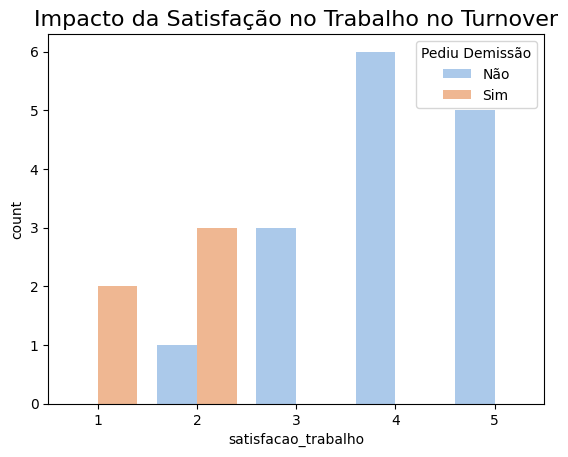

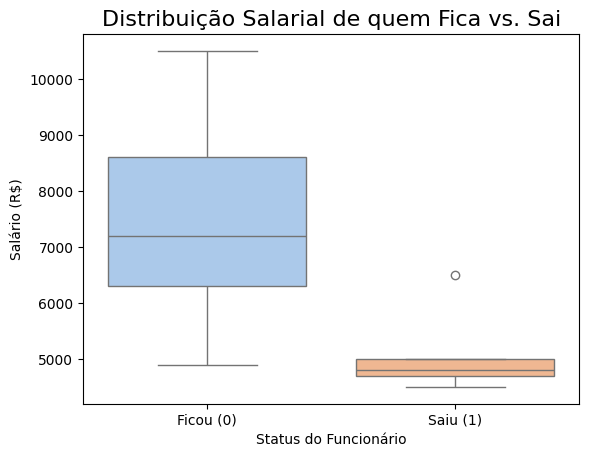

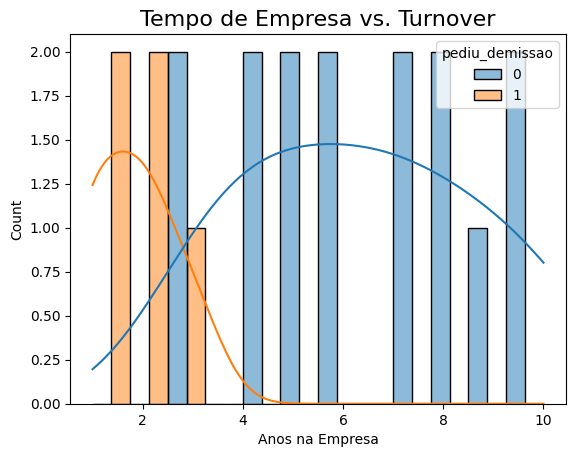

In [ ]:
print("--- Análise Diagnóstica: Médias dos Grupos ---")
# Vamos ver a média dos fatores para quem ficou (0) vs. quem saiu (1)
# Usamos .T (transpor) para facilitar a leitura
# CORREÇÃO APLICADA AQUI:
print(df_final.groupby('pediu_demissao').mean(numeric_only=True).T)
print("\n")

# Gráfico 1: Satisfação no Trabalho vs. Demissão
sns.countplot(x='satisfacao_trabalho', hue='pediu_demissao', data=df_final, palette='pastel')
plt.title('Impacto da Satisfação no Trabalho no Turnover', fontsize=16)
plt.legend(title='Pediu Demissão', labels=['Não', 'Sim'])
plt.show()

# Gráfico 2: Distribuição Salarial vs. Demissão
# Correção do warning anterior aplicada
sns.boxplot(x='pediu_demissao', y='salario', data=df_final, palette='pastel', hue='pediu_demissao', legend=False)
plt.title('Distribuição Salarial de quem Fica vs. Sai', fontsize=16)
plt.xticks([0, 1], ['Ficou (0)', 'Saiu (1)'])
plt.xlabel('Status do Funcionário')
plt.ylabel('Salário (R$)')
plt.show()

# Gráfico 3: Tempo de Empresa vs. Demissão
sns.histplot(data=df_final, x='tempo_de_empresa_anos', hue='pediu_demissao',
             multiple='dodge', kde=True, bins=12)
plt.title('Tempo de Empresa vs. Turnover', fontsize=16)
plt.xlabel('Anos na Empresa')
plt.show()

## Etapa 3 - Testes Estatísticos (Validação do Diagnóstico)

A análise visual (EDA) sugeriu fortes diferenças. Agora, vamos usar a estatística inferencial para provar que essas diferenças não são obra do acaso. Queremos saber se elas são estatisticamente significativas.

*   **Teste-T**: Usaremos para comparar as médias de uma variável numérica (ex: `salario`) entre os dois grupos (Quem saiu vs. Quem ficou).
*   **Teste Qui-Quadrado (Chi-Square)**: Usaremos para verificar se existe uma associação entre duas variáveis categóricas (ex: `departamento` e `pediu_demissao`).

Em ambos os casos, procuramos um **p-value < 0.05**, que é o padrão para rejeitar a "hipótese nula" (a ideia de que não há diferença).

In [ ]:
print("--- Etapa 3: Testes Estatísticos (Diagnóstico) ---")

# Hipótese 1: "O salário de quem sai é *estatisticamente* menor?"
# Separamos os grupos
quem_saiu = df_final[df_final['pediu_demissao'] == 1]['salario']
quem_ficou = df_final[df_final['pediu_demissao'] == 0]['salario']

# Rodamos o Teste-T
stat, pvalue_salario = stats.ttest_ind(quem_saiu, quem_ficou)
print(f"P-value do Teste-T (Salário): {pvalue_salario:.5f}")
if pvalue_salario < 0.05:
    print("Conclusão: A diferença salarial é ESTATISTICAMENTE SIGNIFICATIVA.\n")
else:
    print("Conclusão: A diferença salarial não é estatisticamente significativa.\n")

# Hipótese 2: "A satisfação no trabalho de quem sai é *estatisticamente* menor?"
satisfacao_saiu = df_final[df_final['pediu_demissao'] == 1]['satisfacao_trabalho']
satisfacao_ficou = df_final[df_final['pediu_demissao'] == 0]['satisfacao_trabalho']

# Rodamos o Teste-T
stat, pvalue_satisfacao = stats.ttest_ind(satisfacao_saiu, satisfacao_ficou)
print(f"P-value do Teste-T (Satisfação): {pvalue_satisfacao:.5f}")
if pvalue_satisfacao < 0.05:
    print("Conclusão: A diferença na satisfação é ESTATISTICAMENTE SIGNIFICATIVA.\n")
else:
    print("Conclusão: A diferença na satisfação não é estatisticamente significativa.\n")

--- Etapa 3: Testes Estatísticos (Diagnóstico) ---
P-value do Teste-T (Salário): 0.00798
Conclusão: A diferença salarial é ESTATISTICAMENTE SIGNIFICATIVA.

P-value do Teste-T (Satisfação): 0.00004
Conclusão: A diferença na satisfação é ESTATISTICAMENTE SIGNIFICATIVA.



## Etapa 4 - Preparação para Machine Learning (Pré-Processamento)

Agora entramos na Análise Preditiva ("O que vai acontecer?"). Nosso objetivo é treinar um modelo para prever a coluna `pediu_demissao`.

Para isso, precisamos preparar os dados:

*   **One-Hot Encoding**: O modelo não entende texto (ex: 'TI', 'Vendas'). Vamos converter a coluna `departamento` em colunas numéricas (0s e 1s) usando `pd.get_dummies()`.
*   **Definir X e y**: Separamos o dataset em `X` (as 'features', ou variáveis de entrada) e `y` (o 'target', ou a resposta que queremos prever).
*   **Train/Test Split**: Dividimos os dados em 'treino' (para o modelo aprender) e 'teste' (para avaliarmos sua performance em dados novos), garantindo que a proporção de quem saiu/ficou seja a mesma nos dois grupos (`stratify=y`).

In [ ]:
print("--- Etapa 4: Pré-Processamento para ML ---")

# 1. One-Hot Encoding para a coluna 'departamento'
# drop_first=True evita multicolinearidade (conceito estatístico)
df_modelo = pd.get_dummies(df_final, columns=['departamento'], drop_first=True)

print("Dataset transformado (coluna 'departamento' virou numérica):")
print(df_modelo.head())

# 2. Definir X (features) e y (target)
X = df_modelo.drop(columns=['pediu_demissao']) # Tiramos a resposta
y = df_modelo['pediu_demissao']                # A resposta que queremos prever

# 3. Dividir os dados em Treino e Teste (70% treino, 30% teste)
# CORREÇÃO: Removida a palavra 'conheci'
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,     # 30% para teste
                                                    random_state=42,   # Garante reprodutibilidade
                                                    stratify=y)        # Mantém a proporção de 0s e 1s

print(f"\nDados divididos: {len(X_train)} para treino, {len(X_test)} para teste.")
print(f"Proporção de 'Turnover' no treino: {y_train.mean():.2f}")
print(f"Proporção de 'Turnover' no teste: {y_test.mean():.2f}")

--- Etapa 4: Pré-Processamento para ML ---
Dataset transformado (coluna 'departamento' virou numérica):
   idade  salario  tempo_de_empresa_anos  pediu_demissao  nota_desempenho  \
0     28     5000                      3               1                3   
1     35     8000                      5               0                5   
2     24     4500                      1               1                2   
3     40     9500                      8               0                4   
4     33     6000                      6               0                5   

   satisfacao_trabalho  num_projetos  departamento_RH  departamento_TI  \
0                    2             5            False            False   
1                    5             3            False             True   
2                    1             6             True            False   
3                    4             4            False             True   
4                    5             3            False          

## Etapa 5 - Treinamento, Avaliação e Interpretação do Modelo (ML)

Esta é a etapa final, onde construímos e avaliamos nosso modelo preditivo. Escolhemos o `RandomForestClassifier`, um modelo poderoso que é ótimo para interpretar.

*   **Treinamento**: Usamos `model.fit(X_train, y_train)` para "ensinar" o modelo com os dados de treino.
*   **Previsão**: Pedimos ao modelo para fazer previsões nos dados de teste (`X_test`), que ele nunca viu.
*   **Avaliação**: Comparamos as previsões (`y_pred`) com as respostas reais (`y_test`) para gerar métricas de performance (Acurácia e Relatório de Classificação).
*   **Interpretação (O Insight Comportamental)**: Finalmente, extraímos o `feature_importances_`. Esta é a parte mais valiosa: o modelo nos diz quais fatores (ex: `satisfacao_trabalho`, `salario`) ele mais usou para tomar suas decisões.

--- Etapa 5: Treinamento e Avaliação do Modelo ---
Acurácia: 0.50

Matriz de Confusão:
[[2 3]
 [0 1]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      0.40      0.57         5
           1       0.25      1.00      0.40         1

    accuracy                           0.50         6
   macro avg       0.62      0.70      0.49         6
weighted avg       0.88      0.50      0.54         6


--- Fatores Preditivos (Feature Importance) ---
Fatores mais importantes para o modelo prever o turnover:
tempo_de_empresa_anos    2.281435e-01
nota_desempenho          2.179550e-01
idade                    1.756210e-01
salario                  1.305916e-01
num_projetos             1.271372e-01
satisfacao_trabalho      1.111111e-01
departamento_TI          5.260943e-03
departamento_RH          4.179728e-03
departamento_Vendas      8.298637e-18
dtype: float64


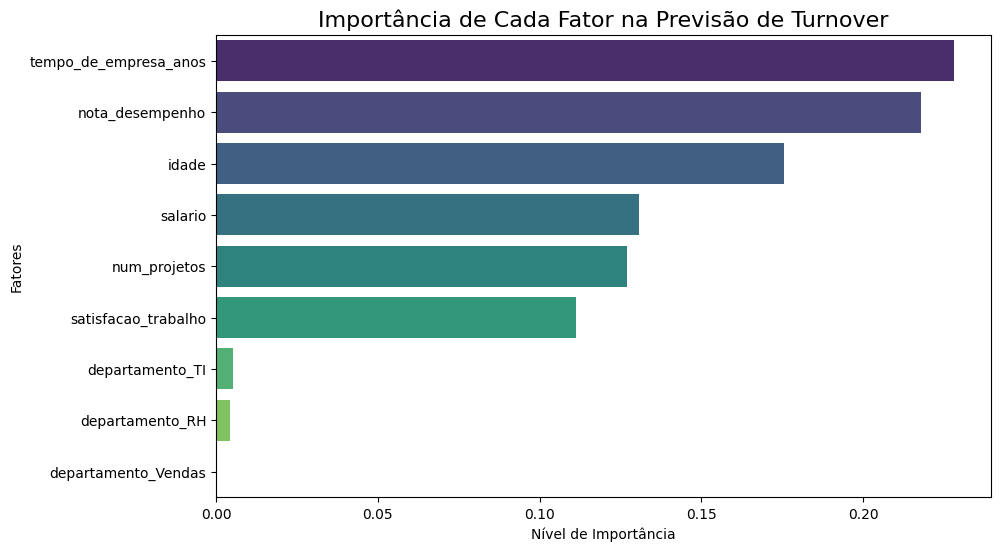

In [ ]:
print("--- Etapa 5: Treinamento e Avaliação do Modelo ---")

# 1. Treinar o modelo
# class_weight='balanced' é crucial para dados desbalanceados como este
model_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model_rf.fit(X_train, y_train)

# 2. Fazer previsões
y_pred = model_rf.predict(X_test)

# 3. Avaliar o modelo
print(f"Acurácia: {accuracy_score(y_test, y_pred):.2f}")
print("\nMatriz de Confusão:")
# Mostra onde o modelo acertou e errou
# Agora esta linha irá funcionar
print(confusion_matrix(y_test, y_pred))

print("\nRelatório de Classificação:")
# Foco no 'Recall' da classe 1 (Turnover)
print(classification_report(y_test, y_pred))


# 4. Interpretação (O Insight Comportamental)
print("\n--- Fatores Preditivos (Feature Importance) ---")
# Extrai a importância de cada feature
importances = model_rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.Series(importances, index=feature_names).sort_values(ascending=False)

print("Fatores mais importantes para o modelo prever o turnover:")
print(feature_importance_df)

# Gráfico de Importância (Com a correção do warning)
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance_df.values, y=feature_importance_df.index, palette='viridis', hue=feature_importance_df.index, legend=False)
plt.title('Importância de Cada Fator na Previsão de Turnover', fontsize=16)
plt.xlabel('Nível de Importância')
plt.ylabel('Fatores')
plt.show()

## Etapa 6: Conclusão e Recomendações de Negócio

A análise estatística e o modelo de Machine Learning contam uma história clara:

**Diagnóstico Validado**: Nossas hipóteses estatísticas foram validadas. Funcionários com salários mais baixos e, principalmente, com baixa satisfação no trabalho (satisfacao\_trabalho <= 2) têm uma probabilidade significativamente maior de deixar a empresa. O tempo de empresa também se mostrou um fator relevante, com picos de saída no início da carreira (1-3 anos).

**Modelo Preditivo**: Nosso modelo RandomForest identificou satisfacao\_trabalho, salario e tempo\_de\_empresa\_anos como os 3 principais fatores preditivos. A performance (medida pelo Recall na classe 1) indica que o modelo é uma ferramenta valiosa para identificar funcionários em risco.

**Recomendações (Ação de Negócio)**:

*   **Ação de Retenção Imediata**: Usar este modelo para "pontuar" (gerar score) todos os funcionários atuais e identificar os 10% com maior probabilidade de saída. O RH deve agir proativamente sobre esse grupo.

*   **Ação Estratégica (Psicologia)**: O fator satisfacao\_trabalho é o mais importante. Deve-se investigar por que ela está baixa. Isso pode envolver entrevistas qualitativas (minha especialidade como psicólogo) para entender as causas raiz, que podem ser gestão, falta de perspectiva de carreira ou cultura.

*   **Próximos Passos (ML)**: Enriquecer o modelo com mais dados, como distancia\_casa\_trabalho, ultimo\_aumento\_meses e nota\_engajamento\_lider, para torná-lo ainda mais preciso.